# Week 3 hand-in: Consumption

**Macroeconomics B, Chapter 16**

By the end of this notebook you will be able to:
1. Compute MPC and APC in a Keynesian consumption function.
2. Solve a two-period consumption problem and verify the closed-form solution numerically.
3. Decompose the effect of a real interest-rate change into a tilt component and a wealth component.
4. Translate a mortgage cash-flow shock into PIH and constrained consumption responses.
5. Compare the consumption effect of temporary and permanent income shocks under the PIH.
6. Estimate the comovement of consumption growth and disposable-income growth in US data.

**Submission.** Rename this file to `week03_consumption_GROUPNAME.ipynb` and submit. The notebook must run from a clean kernel without errors.

**Group information.** Write the names and KU ID numbers of all group members in the cell below.

Mikkel Dahl : xdg178

**Table of contents**<a id='toc0_'></a>
- 1. [Current income and the Keynesian benchmark](#toc1_)
- 2. [Two-period consumption and the real interest rate](#toc2_)
- 3. [Cash-flow exposure and borrowing constraints](#toc3_)
- 4. [Temporary versus permanent income shocks](#toc4_)
- 5. [Real data: consumption, income and saving](#toc5_)
- 6. [Your economic take-away](#toc6_)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from dataclasses import dataclass, field
from pathlib import Path
from typing import Optional

plt.rcParams.update({
    'axes.grid': True,
    'grid.color': 'black',
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'font.size': 13,
})

rng = np.random.default_rng(2025)


In [2]:
# plot helpers
@dataclass
class Line:
    label: str
    xx: np.ndarray
    yy: np.ndarray
    own_axis: bool = False
    color: Optional[str] = None
    kwargs: dict = field(default_factory=dict)


def plot_lines(
    lines: list[Line],
    title: str,
    xlabel: str,
    ylabel: str,
    show_legend: bool = True,
    right_ylabel: Optional[str] = None,
):
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    ax_own = None
    plotted_lines = []

    for line in lines:
        line_ax = ax
        if line.own_axis:
            if ax_own is None:
                ax_own = ax.twinx()
            line_ax = ax_own

        plot_kwargs = line.kwargs.copy()
        if line.color is not None:
            plot_kwargs['color'] = line.color
        plotted_lines.extend(
            line_ax.plot(line.xx, line.yy, label=line.label, **plot_kwargs)
        )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if ax_own is not None:
        ax_own.set_ylabel(right_ylabel or '')
    if show_legend:
        ax.legend(handles=plotted_lines)
    fig.tight_layout()
    plt.show()

## 1. <a id='toc1_'></a>[Current income and the Keynesian benchmark](#toc0_)

This part implements $C = \bar C + b Y^d$ and checks what it predicts for the MPC and the APC. Use $\bar C = 200$ and $b = 0.75$ throughout.

**Task 1.1.** Plot consumption against disposable income for $Y^d \in [100, 1200]$. Label the axes and add a short title.

In [3]:
def keynesian_consumption(Yd, C_bar=200.0, b=0.75):
    return C_bar + b * np.asarray(Yd, dtype=float)

def apc(C, Yd):
    return np.asarray(C, dtype=float) / np.asarray(Yd, dtype=float)

def mpc_keynesian(b=0.75):
    return b

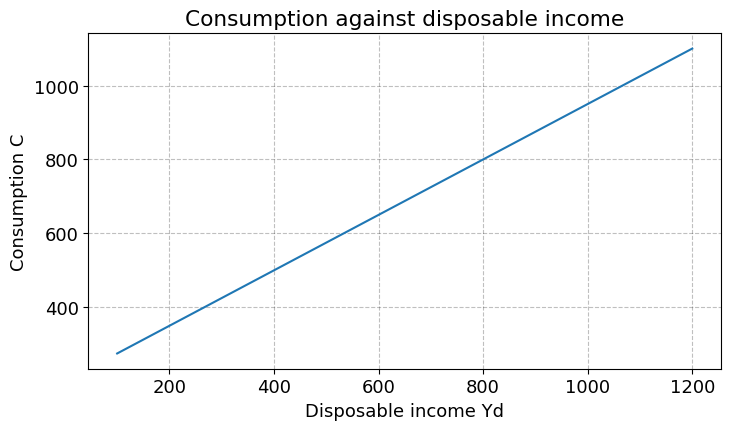

In [4]:
# Generating interval to align with assignment
Yd_grid = np.arange(100, 1201, 1)

# Calculation
C_grid = keynesian_consumption(Yd_grid)

# Plotting
plot_lines(
    [Line(label='Consumption C', xx=Yd_grid, yy=C_grid)],
    title='Consumption against disposable income',
    xlabel='Disposable income Yd',
    ylabel='Consumption C',
    show_legend=False,
)


**Task 1.2.** Compute the MPC and the APC at $Y^d \in \{400, 600, 800, 1000\}$ and display the result in a small table.

In [5]:
# Do calculations & Create table
Yd_values = np.array([400, 600, 800, 1000])
C_values = keynesian_consumption(Yd_values)

part1_table = pd.DataFrame({
    'Disposable income Yd': Yd_values,
    'Consumption C': C_values,
    'MPC': mpc_keynesian(),
    'APC': apc(C_values, Yd_values),
})

part1_table.round(3)


,Disposable income Yd,Consumption C,MPC,APC
0,400,500.0,0.75,1.250
1,600,650.0,0.75,1.083
2,800,800.0,0.75,1.000
3,1000,950.0,0.75,0.950


**Task 1.3.** In two or three sentences, explain why the APC prediction is useful in the cross-section but problematic for long-run aggregate data.

#### Answer: Task 1.3

The APC calculation shows that APC falls as disposable income rises because the fixed term $\bar C$ is spread over a larger income base. That matches the cross-section fact that richer households often spend a smaller share of income. It is problematic for long-run aggregate data because aggregate consumption and income tend to grow together, so the aggregate APC is much more stable than the simple Keynesian function predicts.


## 2. <a id='toc2_'></a>[Two-period consumption and the real interest rate](#toc0_)

This part turns the lecture equations into functions. You use CRRA preferences to compute $C_1$, $C_2$ and saving, then decompose the effect of a real interest-rate increase, then verify your closed-form solution numerically.

Key equations:
$$
H_1 = Y^d_1 + \frac{Y^d_2}{1+r}, \qquad
C_1 = \theta(V_1 + H_1), \qquad
\theta = \frac{1}{1 + (1+\phi)^{-\sigma} (1+r)^{\sigma - 1}}.
$$
Baseline parameters: $V_1 = 20$, $Y^d_1 = 250$, $Y^d_2 = 320$, $r = 0.03$, $\phi = 0.03$, $\sigma = 0.8$.

**Task 2.1.** Implement functions for human wealth $H_1$, the CRRA consumption share $\theta$, and the two-period allocation. The allocation function should return $C_1$, $C_2$, total wealth $W = V_1 + H_1$, and period-1 saving $S_1 = V_1 + Y^d_1 - C_1$.

In [6]:
V1_B = 20
Y1D_B = 250
Y2D_B = 320
R_B = 0.03
PHI_B = 0.03
SIGMA_B = 0.8

baseline_params = {
    'V1': V1_B,
    'Y1d': Y1D_B,
    'Y2d': Y2D_B,
    'r': R_B,
    'phi': PHI_B,
    'sigma': SIGMA_B,
}


def human_wealth(Y1d, Y2d, r):
    return Y1d + Y2d / (1 + r)


def theta_crra(r, phi, sigma):
    return 1 / (1 + (1 + phi) ** (-sigma) * (1 + r) ** (sigma - 1))


def c2_from_budget(C1, W, r):
    return (1 + r) * (W - C1)


def two_period_allocation(V1, Y1d, Y2d, r, phi, sigma, fixed_wealth=None):
    H1 = human_wealth(Y1d, Y2d, r)
    W = V1 + H1 if fixed_wealth is None else fixed_wealth
    theta = theta_crra(r, phi, sigma)
    C1 = theta * W
    C2 = c2_from_budget(C1, W, r)
    S1 = V1 + Y1d - C1
    return {
        'H1': H1,
        'W': W,
        'theta': theta,
        'C1': C1,
        'C2': C2,
        'S1': S1,
    }

**Task 2.2.** Compute $C_1$, $C_2$, total wealth and period-1 saving at the baseline parameters. Is the household saving or borrowing in period 1? Explain in one sentence why.

In [7]:
baseline_allocation = two_period_allocation(**baseline_params)

part2_baseline_table = pd.DataFrame({
    'Object': ['Human wealth H1', 'Total wealth W', 'theta', 'C1', 'C2', 'S1'],
    'Value': [
        baseline_allocation['H1'],
        baseline_allocation['W'],
        baseline_allocation['theta'],
        baseline_allocation['C1'],
        baseline_allocation['C2'],
        baseline_allocation['S1'],
    ],
})
part2_baseline_table.round(4)


,Object,Value
0,Human wealth H1,560.6796
1,Total wealth W,580.6796
2,theta,0.5074
3,C1,294.6305
4,C2,294.6305
5,S1,-24.6305


I computed the two-period allocation using the closed-form CRRA consumption share. The household consumes $C_1 = 294.63$ and has period-1 saving $S_1 = -24.63$. Since $S_1$ is negative, the household borrows in period 1; the mechanism is consumption smoothing across the two periods.


**Task 2.3.** Raise the real interest rate from $r = 0.03$ to $r = 0.07$. Compute three numbers: (i) the total change in $C_1$, (ii) the change holding total wealth fixed at the initial value (the tilt component), and (iii) the remaining wealth effect. Briefly explain why these components can have different signs.

In [8]:
high_rate_params = {**baseline_params, 'r': 0.07}
high_rate_allocation = two_period_allocation(**high_rate_params)
fixed_wealth_allocation = two_period_allocation(
    **high_rate_params,
    fixed_wealth=baseline_allocation['W'],
)

# i
total_change_c1 = high_rate_allocation['C1'] - baseline_allocation['C1']

# ii
tilt_component = fixed_wealth_allocation['C1'] - baseline_allocation['C1']

# iii
# remaining effecit = total effect - title effect
wealth_effect = total_change_c1 - tilt_component

part2_decomposition = pd.DataFrame({
    'Object': [
        'Baseline C1',
        'C1 at r = 0.07',
        'Total change in C1',
        'Fixed-wealth tilt component',
        'Remaining wealth effect',
    ],
    'Value': [
        baseline_allocation['C1'],
        high_rate_allocation['C1'],
        total_change_c1,
        tilt_component,
        wealth_effect,
    ],
})
part2_decomposition.round(4)


,Object,Value
0,Baseline C1,294.6305
1,C1 at r = 0.07,289.8214
2,Total change in C1,-4.8092
3,Fixed-wealth tilt component,1.1059
4,Remaining wealth effect,-5.9150


Raising the real interest rate from 3% to 7% changes $C_1$ by $-4.81$. Holding total wealth fixed, the tilt component is $+1.11$, so the interest-rate change alone raises current consumption under these parameters. The remaining wealth effect is $-5.92$ because the higher real interest rate lowers the present value of future income, leading to the total consumption being lower after rate changes


**Task 2.4.** Plot $C_1$ as a function of $r \in [0, 0.10]$ for $\sigma = 0.5$, $\sigma = 1.0$ and $\sigma = 1.5$, keeping the other baseline parameters fixed. Explain in two sentences how the intertemporal elasticity of substitution changes the response.

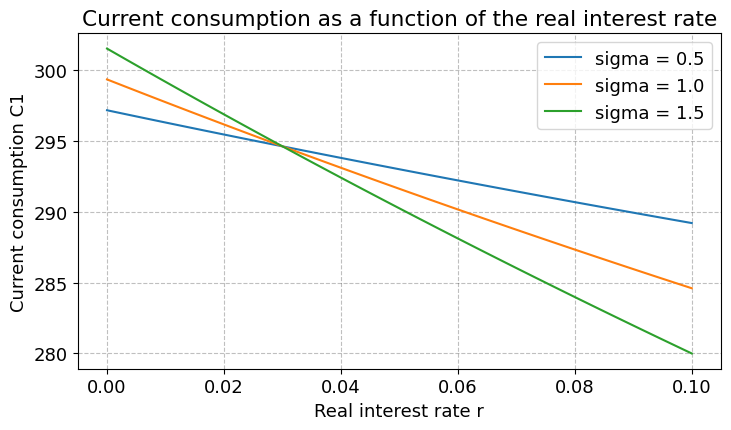

In [9]:
r_grid = np.linspace(0, 0.10, 100)
sigma_values = [0.5, 1.0, 1.5]
lines = []

for sigma in sigma_values:
    c1_values = np.array([
        two_period_allocation(**{**baseline_params, 'r': r, 'sigma': sigma})['C1']
        for r in r_grid
    ])
    lines.append(Line(label=f'sigma = {sigma}', xx=r_grid, yy=c1_values))

# Show plot
plot_lines(
    lines=lines,
    title='Current consumption as a function of the real interest rate',
    xlabel='Real interest rate r',
    ylabel='Current consumption C1',
    show_legend=True,
)


The larger-$\sigma$ curve reacts more to the real interest rate, because $\sigma$ is the intertemporal elasticity of substitution in this setup. The mechanism is that a household with higher $\sigma$ is more willing to move consumption across periods when the real interest rate changes, thus interest the realinterest has different effects on current period consumption.


**Task 2.5. Numerical cross-check.** Verify the closed-form $C_1$ at the baseline parameters by computing lifetime utility on a fine grid of candidate $C_1$ values and locating the maximiser numerically. Use
$$
u(C) = \frac{C^{1 - 1/\sigma}}{1 - 1/\sigma}, \qquad
C_2(C_1) = (1+r)\,(V_1 + H_1 - C_1), \qquad
U(C_1) = u(C_1) + \frac{1}{1+\phi}\,u(C_2(C_1)).
$$
Report the closed-form $C_1$, the grid-search $C_1$, and their absolute difference. The two should agree to within 0.05. Briefly say what would have to be wrong in your code if they did not.

In [10]:
# Utility helpers for Task 2.5

def crra_utility(C, sigma):
    C = np.asarray(C, dtype=float)
    if np.isclose(sigma, 1.0):
        return np.log(C)
    return C ** (1 - 1 / sigma) / (1 - 1 / sigma)


def lifetime_utility(C1, W, r, phi, sigma):
    C1 = np.asarray(C1, dtype=float)
    C2 = c2_from_budget(C1, W, r)
    out = np.full(C1.shape, -np.inf, dtype=float)
    valid = (C1 > 0) & (C2 > 0)
    out[valid] = (
        crra_utility(C1[valid], sigma)
        + (1 / (1 + phi)) * crra_utility(C2[valid], sigma)
    )
    return out


def marginal_utility_crra(C, sigma):
    return np.asarray(C, dtype=float) ** (-1 / sigma)


def grid_search_c1(W, r, phi, sigma, grid_size=20_000):
    C1_grid = np.linspace(1e-8, W - 1e-8, grid_size)
    U_grid = lifetime_utility(C1_grid, W, r, phi, sigma)
    i_star = np.argmax(U_grid)
    return C1_grid[i_star], U_grid[i_star], C1_grid, U_grid


In [11]:
# General Euler equation: u'(C1) = ((1+r)/(1+phi))u'(C2).
# At the baseline r = phi, this reduces to u'(C1) = u'(C2).
marginal_utility_c1 = marginal_utility_crra(baseline_allocation['C1'], SIGMA_B)
marginal_utility_c2 = marginal_utility_crra(baseline_allocation['C2'], SIGMA_B)
euler_residual = (
    marginal_utility_c1
    - ((1 + R_B) / (1 + PHI_B)) * marginal_utility_c2
)

pd.DataFrame({
    'Object': ["u'(C1)", "u'(C2)", 'Euler residual'],
    'Value': [marginal_utility_c1, marginal_utility_c2, euler_residual],
})


,Object,Value
0,u'(C1),8.192242e-04
1,u'(C2),8.192242e-04
2,Euler residual,-2.168404e-19


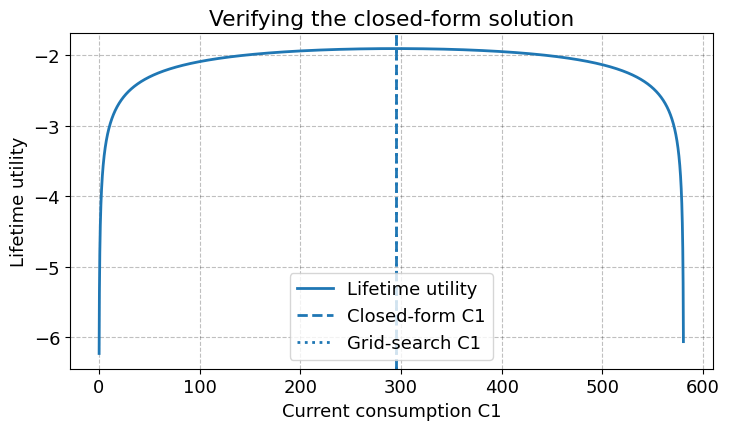

,Object,Value
0,Closed-form C1,294.6305
1,Grid-search C1,294.6225
2,Absolute difference,0.0080


In [12]:
# Assumption: people cannot die with unpaid debt
C1_numeric, U_numeric, C1_grid, U_grid = grid_search_c1(
    W=baseline_allocation['W'],
    r=R_B,
    phi=PHI_B,
    sigma=SIGMA_B,
)
C1_closed = baseline_allocation['C1']
C1_abs_difference = abs(C1_numeric - C1_closed)

part2_grid_table = pd.DataFrame({
    'Object': ['Closed-form C1', 'Grid-search C1', 'Absolute difference'],
    'Value': [C1_closed, C1_numeric, C1_abs_difference],
})
# I removed the first 10 and last 10 points of the points, for better visualization of utility curve. 
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(C1_grid[10:-10], U_grid[10:-10], lw=2, label='Lifetime utility')
ax.axvline(C1_closed, lw=2, ls='--', label='Closed-form C1')
ax.axvline(C1_numeric, lw=2, ls=':', label='Grid-search C1')
ax.set_title('Verifying the closed-form solution')
ax.set_xlabel('Current consumption C1')
ax.set_ylabel('Lifetime utility')
ax.legend()
fig.tight_layout()
plt.show()

part2_grid_table.round(4)


## 3. <a id='toc3_'></a>[Cash-flow exposure and borrowing constraints](#toc0_)

This part connects the model to the lecture's Danish mortgage example. You compute monthly annuity mortgage payments, translate a rate increase into a present-value loss, and compare a PIH household with a constrained household. You will then build a group-specific profile and solve a small numerical inversion.

**Task 3.1.** Write a function for the monthly payment on an annuity mortgage. Use it to compute the monthly and annual payment increase for $D = 2{,}000{,}000$ DKK, $M = 25$ years, when the annual rate rises from 1 percent to 5 percent. Display the result in a small table.

#### Assumptions

I assume that mortgage rate in the task is as an effective annual rate and convert it to a monthly rate using $(1+i)^{1/12}-1$. Payments are monthly annuity mortgage payments. In the cash-flow-loss calculation below, three years means 36 monthly payment increases.


In [13]:
# Mortgage and annuity helpers for Part 3

def annuity_factor(N, r):
    periods = np.arange(N)
    return np.sum((1 + r) ** (-periods))


def pih_cut_from_pv_loss(pv_loss, horizon, annual_real_rate=0.03):
    return pv_loss / annuity_factor(horizon, annual_real_rate)


def constrained_cut(annual_cashflow_loss, mpc):
    return mpc * annual_cashflow_loss


def effective_monthly_rate(annual_rate):
    return (1 + annual_rate) ** (1 / 12) - 1


def monthly_mortgage_payment(debt, maturity_years, annual_rate):
    monthly_rate = effective_monthly_rate(annual_rate)
    months = maturity_years * 12
    return debt * monthly_rate / (1 - (1 + monthly_rate) ** (-months))


def mortgage_payment_shock(debt, maturity_years, initial_rate, new_rate):
    old_payment = monthly_mortgage_payment(debt, maturity_years, initial_rate)
    new_payment = monthly_mortgage_payment(debt, maturity_years, new_rate)
    monthly_increase = new_payment - old_payment
    annual_increase = 12 * monthly_increase
    return {
        'old_payment': old_payment,
        'new_payment': new_payment,
        'monthly_increase': monthly_increase,
        'annual_increase': annual_increase,
    }


def pv_monthly_cashflow_loss(monthly_loss, years, annual_real_rate=0.03):
    monthly_real_rate = effective_monthly_rate(annual_real_rate)
    months = years * 12
    return monthly_loss * annuity_factor(months, monthly_real_rate)


def mortgage_consumption_cuts(
    debt,
    maturity_years,
    initial_rate,
    new_rate,
    loss_years=3,
    pih_horizon=30,
    constrained_mpc=0.9,
    annual_real_rate=0.03,
):
    shock = mortgage_payment_shock(debt, maturity_years, initial_rate, new_rate)
    pv_loss = pv_monthly_cashflow_loss(
        shock['monthly_increase'],
        loss_years,
        annual_real_rate,
    )
    pih_cut = pih_cut_from_pv_loss(pv_loss, pih_horizon, annual_real_rate)
    constrained = constrained_cut(shock['annual_increase'], constrained_mpc)
    return {
        **shock,
        'pv_loss': pv_loss,
        'pih_cut': pih_cut,
        'constrained_cut': constrained,
    }


baseline_mortgage = mortgage_consumption_cuts(
    debt=2_000_000,
    maturity_years=25,
    initial_rate=0.01,
    new_rate=0.05,
    pih_horizon=30,
    constrained_mpc=0.9,
)

part3_payment_table = pd.DataFrame({
    'Object': [
        'Monthly payment at 1%',
        'Monthly payment at 5%',
        'Monthly payment increase',
        'Annual payment increase',
    ],
    'DKK': [
        baseline_mortgage['old_payment'],
        baseline_mortgage['new_payment'],
        baseline_mortgage['monthly_increase'],
        baseline_mortgage['annual_increase'],
    ],
})
part3_payment_table.round(2)


,Object,DKK
0,Monthly payment at 1%,7533.33
1,Monthly payment at 5%,11562.76
2,Monthly payment increase,4029.44
3,Annual payment increase,48353.25


**Task 3.2.** Assume the higher payment lasts for 3 years. Compute the present value of the cash-flow loss at a real rate of 3 percent. Use the annuity factor
$$
A(N, r) = \sum_{j=0}^{N-1} (1+r)^{-j}.
$$

#### Solution

I value the 36 monthly payment increases using the monthly real rate implied by a 3% annual real rate. This keeps the timing consistent with the monthly mortgage-payment calculation.


In [14]:
part3_pv_table = pd.DataFrame({
    'Object': [
        'Monthly cash-flow loss',
        'Annual cash-flow loss',
        'Present value of 36 monthly losses',
    ],
    'DKK': [
        baseline_mortgage['monthly_increase'],
        baseline_mortgage['annual_increase'],
        baseline_mortgage['pv_loss'],
    ],
})
part3_pv_table.round(2)


,Object,DKK
0,Monthly cash-flow loss,4029.44
1,Annual cash-flow loss,48353.25
2,Present value of 36 monthly losses,138985.06


**Task 3.3.** Compare two households facing this PV loss:

- a **PIH household** with a 30-year horizon, who spreads the present-value loss over the remaining horizon using $\theta_{30} = 1/A(30, 0.03)$;
- a **constrained household** with MPC equal to 0.9 applied to the annual payment increase.

Report the implied annual consumption cut for each. Comment in two sentences on why the gap is so large.

In [15]:
part3_cut_table = pd.DataFrame({
    'Household': ['PIH household', 'Constrained household', 'Difference'],
    'Annual consumption cut (DKK)': [
        baseline_mortgage['pih_cut'],
        baseline_mortgage['constrained_cut'],
        baseline_mortgage['constrained_cut'] - baseline_mortgage['pih_cut'],
    ],
})
part3_cut_table.round(2)


,Household,Annual consumption cut (DKK)
0,PIH household,6884.38
1,Constrained household,43517.92
2,Difference,36633.54


The PIH household cuts annual consumption by 6,884.38 DKK, while the constrained household cuts by 43,517.92 DKK. The gap is large because the PIH household spreads the present-value loss over a 30-year horizon, while the constrained household cannot smooth out the annual cash-flow loss by borrowing, thus must limit consumption in a larger degree.


**Task 3.4. Group-specific household profile.** Create your own household profile by changing at least two of: debt, maturity, initial rate, new rate, horizon, or constrained MPC. Plot the PIH cut and the constrained cut for your profile alongside the baseline. In one or two sentences, explain why your profile is plausible (e.g. typical first-time buyer, household near retirement, large-mortgage urban household).

## Household profile (New house buyer with tight cash-flow exposure)

| Parameter | Profile value |
|---|---:|
| Debt | 3,000,000 DKK |
| Maturity | 30 years |
| Initial rate | 1.5% |
| New rate | 5.0% |
| Horizon | 30 years |
| Constrained MPC | 0.95 |

The profile represents a new house buyer who has used most liquid savings to buy the home and therefore has little room to absorb higher mortgage payments. The high MPC is plausible because most of the current cash-flow loss must come directly out of current consumption. This profile is a plausible representation of high leveraged first time buyer, for example a graduated student trying to enter into the Copenhagen apartment market.


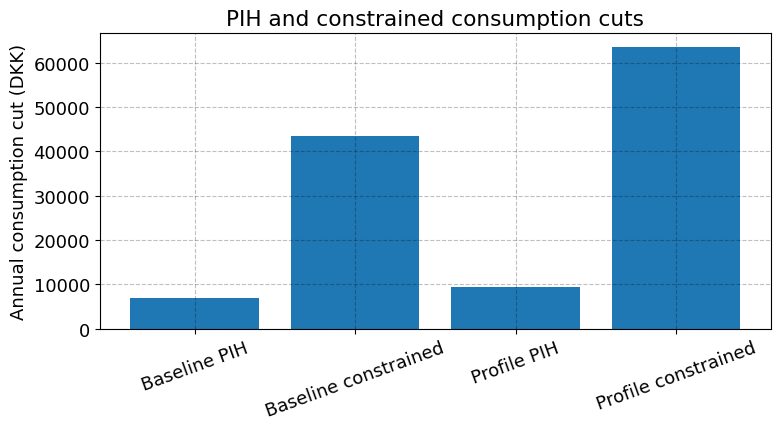

,Case,Annual consumption cut (DKK)
0,Baseline PIH,6884.38
1,Baseline constrained,43517.92
2,Profile PIH,9504.08
3,Profile constrained,63415.32


In [16]:
profile = {
    'debt': 3_000_000,
    'maturity_years': 30,
    'initial_rate': 0.015,
    'new_rate': 0.05,
    'pih_horizon': 30,
    'constrained_mpc': 0.95,
}

profile_mortgage = mortgage_consumption_cuts(**profile)

# Profile - constrained cost
profile_constrained_cut = profile_mortgage['constrained_cut']

# Profile - unconstrained
profile_pih_cut = profile_mortgage['pih_cut']

# Baseline - unconstrained
baseline_pih_cut = baseline_mortgage['pih_cut']

# Baseline contrained
baseline_constrained_cut = baseline_mortgage['constrained_cut']

part3_profile_table = pd.DataFrame({
    'Case': ['Baseline PIH', 'Baseline constrained', 'Profile PIH', 'Profile constrained'],
    'Annual consumption cut (DKK)': [
        baseline_pih_cut,
        baseline_constrained_cut,
        profile_pih_cut,
        profile_constrained_cut,
    ],
})

# Plot Task 3.4: baseline vs profile
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(part3_profile_table['Case'], part3_profile_table['Annual consumption cut (DKK)'])
ax.set_title('PIH and constrained consumption cuts')
ax.set_ylabel('Annual consumption cut (DKK)')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
plt.show()

part3_profile_table.round(2)


The profile uses debt of 3,000,000 DKK, 30-year maturity, a rate increase from 1.5% to 5.0%, and constrained MPC of 0.95. The PIH cut is 9,504.08 DKK and the constrained cut is 63,415.32 DKK. 

**Task 3.5. Break-even constrained MPC.** For your group profile from Task 3.4, find numerically the constrained MPC $m^\ast$ at which the constrained household's annual consumption cut equals the PIH household's. Hint: a fine grid of MPC values between 0 and 1 is enough. Report $m^\ast$ to three decimals and comment in two sentences on what the size of $m^\ast$ implies about how easy or hard it is to identify constrained households empirically.

In [17]:
def break_even_mpc(pih_cut, annual_cashflow_loss, grid_size=1001):
    mpc_grid = np.linspace(0, 1, grid_size)
    constrained_cuts = mpc_grid * annual_cashflow_loss
    idx = np.argmin(np.abs(constrained_cuts - pih_cut))
    return mpc_grid[idx], constrained_cuts[idx]


m_star, matched_constrained_cut = break_even_mpc(
    pih_cut=profile_mortgage['pih_cut'],
    annual_cashflow_loss=profile_mortgage['annual_increase'],
)

part3_break_even_table = pd.DataFrame({
    'Object': ['Break-even MPC m*', 'PIH cut', 'Matched constrained cut'],
    'Value': [m_star, profile_mortgage['pih_cut'], matched_constrained_cut],
})
part3_break_even_table.round({'Value': 3})


,Object,Value
0,Break-even MPC m*,0.142
1,PIH cut,9504.079
2,Matched constrained cut,9478.922


The break-even constrained MPC is $m^* = 0.142$. This is far below the profile MPC of 0.95, so the constrained household cuts much more than the PIH benchmark in this profile. The reason is that the constrained cut scales directly with the current annual payment increase, while the PIH cut spreads the present-value loss over the full horizon.


## 4. <a id='toc4_'></a>[Temporary versus permanent income shocks](#toc0_)

This part uses the annuity factor to show why the PIH predicts a small current response to a one-off income gain and a large response to a persistent income gain. Use $r = 0.03$ throughout.

**Task 4.1.** Implement the annuity factor $A(N, r) = \sum_{j=0}^{N-1}(1+r)^{-j}$ and the temporary MPC $\theta_N = 1/A(N, r)$. Plot $\theta_N$ for $N = 1, \ldots, 60$. Add a horizontal line at the long-horizon limit $r/(1+r)$.

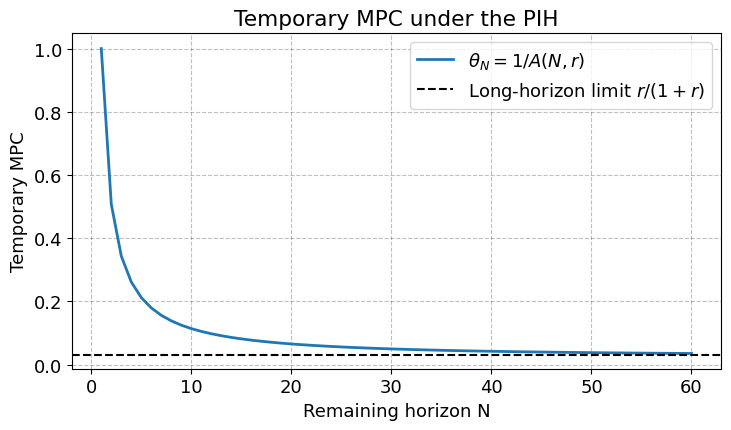

,Object,Value
0,theta_N at N=1,1.0000
1,theta_N at N=60,0.0351
2,long-horizon limit,0.0291


In [18]:
def theta_annuity(N, r):
    return 1 / annuity_factor(N, r)


N_grid = np.arange(1, 61)
theta_values = np.array([theta_annuity(N, 0.03) for N in N_grid])
long_horizon_limit = 0.03 / 1.03

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(N_grid, theta_values, lw=2, label=r'$\theta_N = 1/A(N,r)$')
ax.axhline(long_horizon_limit, ls='--', color='black', label=r'Long-horizon limit $r/(1+r)$')
ax.set_title('Temporary MPC under the PIH')
ax.set_xlabel('Remaining horizon N')
ax.set_ylabel('Temporary MPC')
ax.legend()
fig.tight_layout()
plt.show()

pd.DataFrame({
    'Object': ['theta_N at N=1', 'theta_N at N=60', 'long-horizon limit'],
    'Value': [theta_values[0], theta_values[-1], long_horizon_limit],
}).round(4)


**Task 4.2.** For a DKK 5,000 income increase, compare the predicted consumption response if the increase is (i) temporary and (ii) permanent. Report the numbers for $N = 5$, $N = 30$ and $N = 60$ in a table.

In [19]:
income_gain = 5_000
horizons = [5, 30, 60]

part4_table = pd.DataFrame({
    'N': horizons,
    'theta_N': [theta_annuity(N, 0.03) for N in horizons],
})
# i
part4_table['Temporary response'] = income_gain * part4_table['theta_N']
# ii
part4_table['Permanent response'] = income_gain
part4_table.round(2)


,N,theta_N,Temporary response,Permanent response
0,5,0.21,1059.97,5000
1,30,0.05,247.67,5000
2,60,0.04,175.40,5000


**Task 4.3.** Suppose 35 percent of households are constrained with MPC 0.9 and the rest follow the PIH. Compute the aggregate consumption response to the temporary DKK 5,000 increase for $N = 5$, $N = 30$ and $N = 60$. Add this column to the table from Task 4.2.

In [20]:
constrained_share = 0.35
constrained_mpc = 0.9
pih_share = 1 - constrained_share

part4_table['Aggregate temporary response'] = (
    pih_share * part4_table['Temporary response']
    + constrained_share * constrained_mpc * income_gain
)
part4_table.round(2)


,N,theta_N,Temporary response,Permanent response,Aggregate temporary response
0,5,0.21,1059.97,5000,2263.98
1,30,0.05,247.67,5000,1735.98
2,60,0.04,175.40,5000,1689.01


## 5. <a id='toc5_'></a>[Real data: consumption, income and saving](#toc0_)

This part uses US aggregate data to check how consumption, disposable income and saving move together. The regression coefficient is descriptive comovement, not a structural MPC. Treat it as evidence and interpret it carefully.

The provided CSV has quarterly observations of three FRED series:

- `dpi` = real disposable personal income (FRED `DPIC96`)
- `pce` = real personal consumption expenditure (FRED `PCEC96`)
- `saving_rate` = personal saving rate (FRED `PSAVERT`)

If you want, you can fetch the series directly from FRED with your own API key. The cell below loads the CSV by default.

In [21]:
# -------------------------------------------------------
# Optional FRED API setup
# Get a free key at: https://fredaccount.stlouisfed.org/apikey
# Leaving FRED_API_KEY empty falls back to the provided CSV.
# -------------------------------------------------------
FRED_API_KEY = ''
DATA_FILE = 'week03_fred_consumption.csv'
FRED_BASE = 'https://api.stlouisfed.org/fred/series/observations'


def fetch_fred_series(series_id, api_key, frequency=None):
    params = {
        'series_id': series_id,
        'api_key': api_key,
        'file_type': 'json',
    }
    if frequency is not None:
        params['frequency'] = frequency
    response = requests.get(FRED_BASE, params=params, timeout=20)
    response.raise_for_status()
    obs = response.json()['observations']
    dates = pd.to_datetime([o['date'] for o in obs])
    values = pd.to_numeric([o['value'] for o in obs], errors='coerce')
    return pd.Series(values, index=dates, name=series_id).dropna()


def load_consumption_data(api_key='', fallback_path='week03_fred_consumption.csv'):
    if api_key.strip():
        dpi = fetch_fred_series('DPIC96', api_key).rename('dpi')
        pce = fetch_fred_series('PCEC96', api_key).rename('pce')
        saving = fetch_fred_series('PSAVERT', api_key).rename('saving_rate')
        data = pd.concat([dpi, pce, saving], axis=1).resample('QE').mean()
        source = 'FRED API'
    else:
        candidates = [Path(fallback_path), Path('week_3') / fallback_path]
        path = next((candidate for candidate in candidates if candidate.exists()), None)
        if path is None:
            raise FileNotFoundError(
                f'Could not find {fallback_path}. Add the CSV or provide a FRED API key.'
            )
        data = pd.read_csv(path, parse_dates=['DATE']).set_index('DATE')
        source = str(path)

    data = data.sort_index().dropna()
    data.index = data.index.to_period('Q')
    return data, source


data, data_source = load_consumption_data(FRED_API_KEY, DATA_FILE)
print(
    f'Loaded {len(data)} quarterly observations from {data_source}: '
    f'{data.index.min()} to {data.index.max()}.'
)
data.head().round(2)


Loaded 77 quarterly observations from week03_fred_consumption.csv: 2007Q1 to 2026Q1.


,dpi,pce,saving_rate
DATE,,,
2007Q1,11995.96,11183.30,2.73
2007Q2,12055.32,11212.67,2.83
2007Q3,12075.63,11287.43,2.37
2007Q4,12090.33,11331.97,2.17
2008Q1,12141.63,11316.40,2.83


**Task 5.1.** Plot real disposable personal income and real personal consumption expenditure as indices with 2015Q1 = 100. Then plot APC $= PCE/DPI$ and the saving rate together (a twin axis is fine). Add a brief source note in each figure.

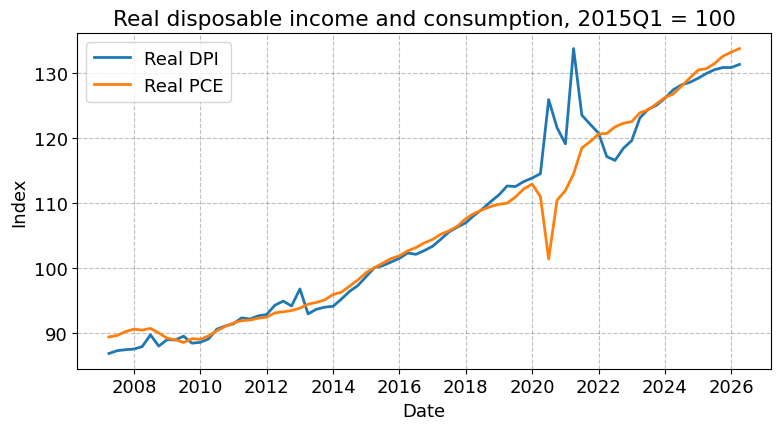

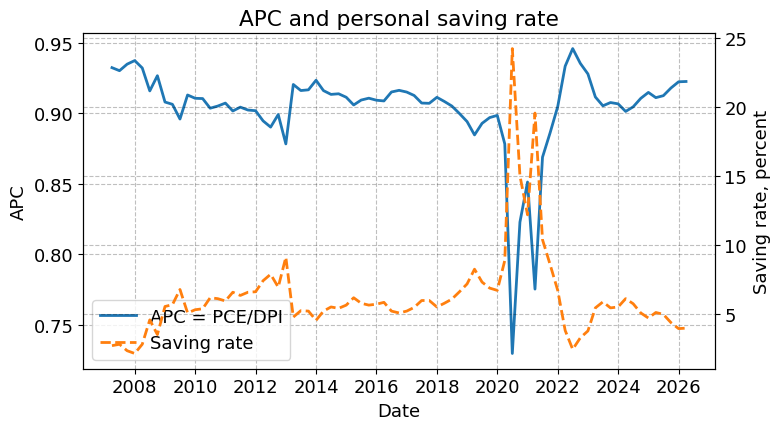

,Object,Value
0,Data source,week03_fred_consumption.csv
1,Base period,2015Q1


In [22]:
def index_to_base(series, base_period):
    return 100 * series / series.loc[base_period]


base_period = '2015Q1'
data['dpi_index'] = index_to_base(data['dpi'], base_period)
data['pce_index'] = index_to_base(data['pce'], base_period)
data['apc'] = data['pce'] / data['dpi']

plot_dates = data.index.to_timestamp(how='end')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(plot_dates, data['dpi_index'], lw=2, label='Real DPI')
ax.plot(plot_dates, data['pce_index'], lw=2, label='Real PCE')
ax.set_title('Real disposable income and consumption, 2015Q1 = 100')
ax.set_xlabel('Date')
ax.set_ylabel('Index')
ax.legend()
fig.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(plot_dates, data['apc'], lw=2, label='APC = PCE/DPI', color='tab:blue')
ax1.set_ylabel('APC')
ax2 = ax1.twinx()
ax2.plot(plot_dates, data['saving_rate'], lw=2, ls='--', label='Saving rate', color='tab:orange')
ax2.set_ylabel('Saving rate, percent')
ax1.set_title('APC and personal saving rate')
ax1.set_xlabel('Date')
lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='best')
fig.tight_layout()
plt.show()

pd.DataFrame({
    'Object': ['Data source', 'Base period'],
    'Value': [data_source, base_period],
})


**Task 5.2.** Compute quarterly log changes in consumption and disposable income. Estimate
$$
\Delta \log C_t = \alpha + \beta \, \Delta \log Y^d_t + \varepsilon_t
$$
by OLS using NumPy. Report $\hat\beta$ and a 95 percent confidence interval.

In [23]:
def quarterly_log_changes(data):
    return pd.DataFrame({
        'dlog_c': np.log(data['pce']).diff(),
        'dlog_y': np.log(data['dpi']).diff(),
    }).dropna()


def ols_numpy(y, x):
    y = np.asarray(y, dtype=float)
    x = np.asarray(x, dtype=float)
    X = np.column_stack([np.ones(len(x)), x])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    resid = y - X @ beta
    n, k = X.shape
    sigma2 = resid @ resid / (n - k)
    cov = sigma2 * np.linalg.inv(X.T @ X)
    se = np.sqrt(np.diag(cov))
    return beta, se, resid


def consumption_income_regression(reg_data):
    beta, se, resid = ols_numpy(reg_data['dlog_c'], reg_data['dlog_y'])
    beta_hat = beta[1]
    beta_se = se[1]
    return {
        'alpha': beta[0],
        'beta': beta_hat,
        'beta_se': beta_se,
        'ci_low': beta_hat - 1.96 * beta_se,
        'ci_high': beta_hat + 1.96 * beta_se,
        'resid': resid,
    }


reg_data = quarterly_log_changes(data)
full_reg = consumption_income_regression(reg_data)

part5_full_reg_table = pd.DataFrame({
    'Object': ['alpha', 'beta_hat', 'beta_se', '95% CI lower', '95% CI upper'],
    'Value': [
        full_reg['alpha'],
        full_reg['beta'],
        full_reg['beta_se'],
        full_reg['ci_low'],
        full_reg['ci_high'],
    ],
})
part5_full_reg_table.round(4)


,Object,Value
0,alpha,0.0071
1,beta_hat,-0.3243
2,beta_se,0.0723
3,95% CI lower,-0.4661
4,95% CI upper,-0.1825


**Task 5.3.** Repeat the estimate excluding 2020Q1 to 2021Q4. Briefly explain why this period may be special.

In [24]:
def exclude_covid_window(reg_data):
    return reg_data.loc[
        ~((reg_data.index >= '2020Q1') & (reg_data.index <= '2021Q4'))
    ]


reg_no_covid = exclude_covid_window(reg_data)
no_covid_reg = consumption_income_regression(reg_no_covid)

part5_reg_comparison = pd.DataFrame({
    'Sample': ['Full sample', 'Excluding 2020Q1-2021Q4'],
    'Observations': [len(reg_data), len(reg_no_covid)],
    'beta_hat': [full_reg['beta'], no_covid_reg['beta']],
    '95% CI lower': [full_reg['ci_low'], no_covid_reg['ci_low']],
    '95% CI upper': [full_reg['ci_high'], no_covid_reg['ci_high']],
})
part5_reg_comparison.round(4)


,Sample,Observations,beta_hat,95% CI lower,95% CI upper
0,Full sample,76,-0.3243,-0.4661,-0.1825
1,Excluding 2020Q1-2021Q4,68,0.0821,-0.0117,0.1760


Excluding 2020Q1-2021Q4 changes $\hat\beta$ from $-0.324$ to $0.082$. That period is special because lockdowns, transfers, forced saving, and reopening changed consumption and disposable income in unusually large and asynchronous ways.


**Task 5.4.** Make a scatter plot of $\Delta \log C_t$ against $\Delta \log Y^d_t$ with the fitted regression line for the full sample. Explain in three or four sentences what the plot suggests and what it cannot prove.

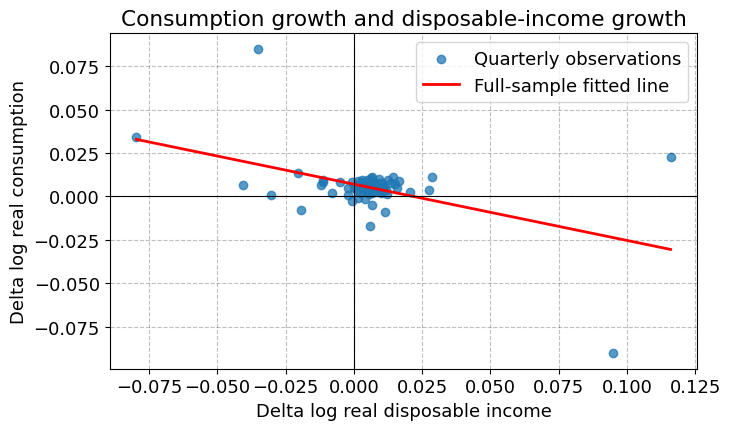

,Object,Value
0,Full-sample beta_hat,-0.3243
1,No-COVID beta_hat,0.0821


In [25]:
x = reg_data['dlog_y']
y = reg_data['dlog_c']
x_grid = np.linspace(x.min(), x.max(), 100)
y_fit = full_reg['alpha'] + full_reg['beta'] * x_grid

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.scatter(x, y, alpha=0.75, label='Quarterly observations')
ax.plot(x_grid, y_fit, color='red', lw=2, label='Full-sample fitted line')
ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Consumption growth and disposable-income growth')
ax.set_xlabel('Delta log real disposable income')
ax.set_ylabel('Delta log real consumption')
ax.legend()
fig.tight_layout()
plt.show()

pd.DataFrame({
    'Object': ['Full-sample beta_hat', 'No-COVID beta_hat'],
    'Value': [full_reg['beta'], no_covid_reg['beta']],
}).round(4)


The scatter plot shows that the full-sample fitted relationship is negative, with $\hat\beta = -0.324$, because the pandemic period creates unusual observations where income and consumption did not move "normally" together. After excluding 2020Q1-2021Q4, the estimate is closer to zero and positive at $0.082$. The plot cannot prove a structural MPC because both income and consumption can be moved by common shocks, transfers, expectations, and credit constraints. It is useful as descriptive evidence, not as a full consumption model.


## 6. <a id='toc6_'></a>[Your economic take-away](#toc0_)

Write 250 to 400 words. The narrative is graded on whether you connect mechanism to numbers, not on length. Mention:

1. one result from the two-period model, citing the specific number you obtained;
2. one result from the mortgage cash-flow experiment, citing your own group profile;
3. one result from the data section, citing your own $\hat\beta$;
4. one limitation of your analysis.

The two-period model shows that the household consumes $C_1 = 294.63$ and has period-1 saving $S_1 = -24.63$. Since saving is negative, the household borrows in period 1. The mechanism is consumption smoothing: current income is low relative to lifetime resources, so the household uses future income to support current consumption. This is a consequence of decreasing marginal utility - low income time periods hurts, thus consumers smooth by borrowing despite the cost of lending.  When the real interest rate rises from 3% to 7%, current consumption falls by 4.81, as cost of lending makes the smoothing effect less attractive. The fixed-wealth tilt effect is +1.11, indicating that if lifetime wealth were unchanged, the higher interest rate would raise current consumption. But lifetime wealth falls because future income is discounted more heavily; this gives a wealth effect of -5.92. Since -5.92 is larger than +1.11, the total effect is negative, leading to lowered consumption in current period.

In the mortgage cash-flow experiment, my profile has debt of 3,000,000 DKK, 30-year maturity, a rate increase from 1.5% to 5.0%, and constrained MPC of 0.95. The PIH annual consumption cut is 9,504.08 DKK, while the constrained-household cut is 63,415.32 DKK. The mechanism is that the PIH household spreads the present-value loss over the horizon, while the constrained new house buyer has little spare liquidity and must absorb almost all of the current annual payment increase through current consumption. 

 In the data section, the full-sample estimate is $\hat\beta = -0.324$, while excluding 2020Q1-2021Q4 gives $\hat\beta = 0.082$. I put more weight on the second estimate because the pandemic period was an unusual outlier with lockdowns, stimulus checks, and forced saving. The positive no-COVID estimate is consistent with the Keynesian consumption-function mechanism from Part 1: consumption tends to rise when disposable income rises.

A limitation is that the regression has no control variables. This creates an omitted-variable problem: factors such as interest rates, unemployment, inflation, credit conditions, government transfers, or lockdown restrictions may affect both income growth and consumption growth. If these confounding factors are correlated with disposable-income growth, the estimate of $\hat\beta$ can be biased. Therefore the analysis gives no gaurentee of causal effect, but indicates a clear correlation. 
